TLDR :

1. Load the aps_failure_training_set.csv dataset.

2. Clean up the data. Transform data. Create new feature if necessary.

3. Define a model for the problem. 

4. Evaluate the model using aps_failure_test_set.csv

5. Discuss performance of the model, any improvements, also make some improvements if obvious.


Predicted class |      True class       |
                |    pos    |    neg    |
-----------------------------------------
pos            |     -     |  Cost_1   |
-----------------------------------------
neg            |  Cost_2   |     -     |
-----------------------------------------
Cost_1 = 10 and cost_2 = 500

Cost of False Negative > Cost of False Positive

5. Number of Instances: 
The training set contains 60000 examples in total in which 
59000 belong to the negative class and 1000 positive class. 
The test set contains 16000 examples. 



# EDA

1. PCA on the 171s atributes2;

In [12]:
import pandas as pd
import numpy as np
"""
1. Scale and do PCA on the attributes. since there are so many
2. Do some form of stratified split since there are 59000 negative class, 1000 positive class
3. Focus on the metric that reduces FN since those are more expensive
"""


'\n1. Scale and do PCA on the attributes. since there are so many\n2. Do some form of stratified split since there are 59000 negative class, 1000 positive class\n3. Focus on the metric that reduces FN since those are more expensive\n'

In [2]:
FILENAME = "data/aps_failure_training_set.csv"
df = pd.read_csv(FILENAME)
df.head()


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [11]:
df.info()
# All of tem seem to be int, there is some NA though
columns_to_exclude = ['class']  # Add other column names you want to exclude

columns_to_convert = [col for col in df.columns if col not in columns_to_exclude]

for col in columns_to_convert:
    df[col] = df[col].replace('na', 0) # replace 'na' with 0
    df[col] = df[col].fillna(0).astype(float)
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: int64(80), object(91)
memory usage: 78.3+ MB
class      object
aa_000    float64
ab_000    float64
ac_000    float64
ad_000    float64
           ...   
ee_007    float64
ee_008    float64
ee_009    float64
ef_000    float64
eg_000    float64
Length: 171, dtype: object


In [14]:
from sklearn.preprocessing import StandardScaler

numeric_cols = columns_to_convert # same
X = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = df['class']

In [21]:
from sklearn.decomposition import PCA

N_COMPONENTS = 30

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=[f'pca_{i}' for i in range(N_COMPONENTS)])

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Shape of original data: {X.shape}")
print(f"Shape after PCA: {X_pca.shape}")
print("\nExplained variance ratio by each component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

Shape of original data: (60000, 170)
Shape after PCA: (60000, 30)

Explained variance ratio by each component:
PC1: 0.2852 (0.2852 cumulative)
PC2: 0.0473 (0.3325 cumulative)
PC3: 0.0410 (0.3735 cumulative)
PC4: 0.0367 (0.4102 cumulative)
PC5: 0.0289 (0.4391 cumulative)
PC6: 0.0235 (0.4625 cumulative)
PC7: 0.0194 (0.4819 cumulative)
PC8: 0.0176 (0.4996 cumulative)
PC9: 0.0176 (0.5172 cumulative)
PC10: 0.0157 (0.5329 cumulative)
PC11: 0.0143 (0.5473 cumulative)
PC12: 0.0138 (0.5611 cumulative)
PC13: 0.0122 (0.5733 cumulative)
PC14: 0.0116 (0.5849 cumulative)
PC15: 0.0113 (0.5962 cumulative)
PC16: 0.0108 (0.6071 cumulative)
PC17: 0.0102 (0.6172 cumulative)
PC18: 0.0101 (0.6273 cumulative)
PC19: 0.0097 (0.6370 cumulative)
PC20: 0.0097 (0.6467 cumulative)
PC21: 0.0093 (0.6560 cumulative)
PC22: 0.0091 (0.6651 cumulative)
PC23: 0.0090 (0.6742 cumulative)
PC24: 0.0087 (0.6829 cumulative)
PC25: 0.0079 (0.6908 cumulative)
PC26: 0.0077 (0.6985 cumulative)
PC27: 0.0076 (0.7061 cumulative)
PC28: 0

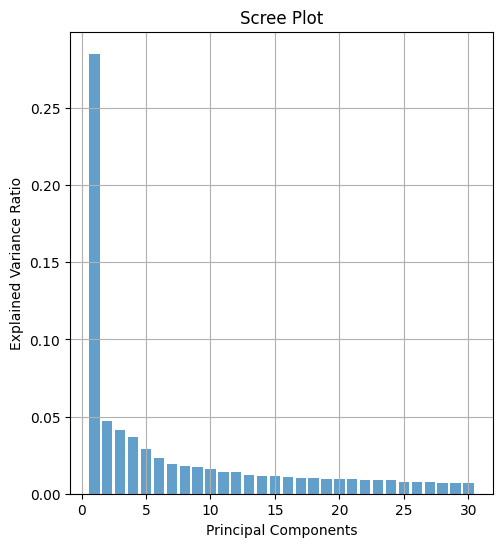

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Individual explained variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, alpha=0.7)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
